# Colored MNIST dataset

In [ ]:
from oxels.datasets import DGPerspectiveDataset
import matplotlib.pyplot as plt

from oxels.models.metrics_mixin import MetricsMixin

dataset = DGPerspectiveDataset(
    path="notebooks/datasets/MNIST",
    dataset="ColoredMNIST",
    h=32,
    w=32,
    split="test",
    domain_split="id",
    seed=0,
)

view1, view2, indices, flags, mask1, mask2 = dataset[6]
plt.subplot(221)
plt.imshow(view1.transpose(1, 2, 0))
plt.axis("off")
plt.subplot(222)
plt.imshow(view2.transpose(1, 2, 0))
plt.axis("off")
plt.subplot(223)
plt.imshow((view2.reshape((-1,3))[indices]*flags[:,None]).reshape(view2.shape).transpose(1, 2, 0))
plt.axis("off")
plt.subplot(224)
plt.imshow(mask1.reshape(view1.transpose(1,2,0).shape[:2]))
plt.axis("off")
plt.show()

# ColoredMNIST Model/Dataset

In [3]:
from collections.abc import Sequence
import os
from torch.utils.data import DataLoader
from torchvision import transforms

from oxels.networks import SimpleUNet
from oxels.models.base_model import BaseModel
from oxels.datasets import DGPerspectiveDataset


class ColoredMNISTModel(BaseModel):
    def __init__(
        self,
        *,
        stage_channels: Sequence[int] = (32, 64, 128, 256),
        num_res_blocks: Sequence[int] = (2, 2, 2, 4),
        num_oxels: int = 64,
        num_norm_groups: int = 8,
        learning_rate: float = 1e-3,
        weight_decay: float = 0.004,
        dropout_stages: Sequence[int],
        dropout: float = 0.1,
        attention_stages: Sequence[int],
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
        lr_pct_start: float = 0.05,
        train_batch_size: int,
        val_batch_size: int,
        image_size: int = 256,
    ):
        num_stages = len(stage_channels)
        has_attention = [False] * num_stages
        for stage in attention_stages:
            has_attention[stage] = True

        residual_dropout = [0.0] * num_stages
        for stage in dropout_stages:
            residual_dropout[stage] = dropout

        backbone = SimpleUNet(
            height=image_size,
            width=image_size,
            in_channels=3,
            out_channels=num_oxels,
            channels_of_stage=stage_channels,
            has_attention=has_attention,
            num_res_blocks=num_res_blocks,
            norm_groups=num_norm_groups,
            residual_dropout=residual_dropout,
        )
        super().__init__(
            backbone=backbone,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            lr_div_factor=lr_div_factor,
            lr_final_div_factor=lr_final_div_factor,
            lr_pct_start=lr_pct_start,
        )
        self.save_hyperparameters()

    def train_dataloader(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="train",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=False,
        )

    def val_dataloader_ood(self):
        dataset = DGPerspectiveDataset(
            path="datasets",
            dataset="ColoredMNIST",
            h=self.hparams.image_size,
            w=self.hparams.image_size,
            split="val",
            domain_split="ood",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((32, 32))
            ]),
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.val_batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=False,
        )


# Training Args, Dataset and Model

In [2]:
import lightning as L
import torch
from lightning.pytorch import callbacks
from lightning.pytorch.loggers import WandbLogger

import wandb
from oxels.callbacks import ShowOxels


torch.cuda.empty_cache()
torch.set_float32_matmul_precision("medium")

print("Device Count:", torch.cuda.device_count())
project = "ColoredMNIST-testing"
total_steps = 30_000
image_size = 32
num_nodes = 1
num_devices = 1
train_batch_size = 128
val_batch_size = 256
learning_rate = 5e-3
lr_pct_start = 0.05
weight_decay = 1e-4

num_stages = 3
num_oxels = 32
base_channels = 32
stage_channels = [32, 64, 64, 128]
num_res_blocks = [1, 2, 2, 4]
stage_channels = stage_channels[:num_stages]
num_res_blocks = num_res_blocks[:num_stages]

dropout_stages = [-2, -1]
dropout = 0.1

attention_stages = [stage for stage in range(4, num_stages)]

model_config = dict(
    stage_channels=stage_channels,
    num_res_blocks=num_res_blocks,
    num_oxels=num_oxels,
    dropout_stages=dropout_stages,
    dropout=dropout,
    attention_stages=attention_stages,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e4,
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    image_size=image_size,
)

trainer_config = dict(
    gradient_clip_val=3.0,
    gradient_clip_algorithm="value",
    max_steps=total_steps,
    accelerator="gpu",
    strategy="auto",
    devices=num_devices,
    precision="16-mixed",
    num_nodes=num_nodes,
)

model = ColoredMNISTModel(**model_config)

with torch.device("cpu"):
    train_images = [model.train_dataloader().dataset.dataset[i][0] for i in range(4)]
    train_images = torch.stack(train_images)
    validation_images = [model.val_dataloader().dataset.dataset[i][0] for i in range(4)]
    validation_images = torch.stack(validation_images)
    validation_images_ood = [model.val_dataloader_ood().dataset.dataset[i][0] for i in range(4)]
    validation_images_ood = torch.stack(validation_images_ood)

num_parameters = sum(p.numel() for p in model.parameters())

config = model_config | trainer_config

Device Count: 1
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.


# Initialize WandB run

In [3]:
run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir="wandb_results",
)

logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters
wandb.summary["model_type"] = "BackboneColoredMNIST"
run_name = wandb.run.name
run_id = wandb.run.id
print(f"name: {run_name} \t run id:{run_id}")

wandb: Currently logged in as: nielsbracher (larskue-tu-dortmund-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


name: amber-terrain-77 	 run id:x73jq8at


# Training

In [4]:
ckpt_dir = os.path.join("lightning_logs", str(run_name))
os.makedirs(ckpt_dir, exist_ok=True)
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "w") as f:
    f.write(run_id)
f.close()
trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
        ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels"),
        ShowOxels(images=validation_images_ood, every_n_epochs=10, caption="Validation OOD Oxels"),
    ],
    logger=logger,
)

try:
    trainer.fit(model)

    result = trainer.callback_metrics["validation/loss"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nbracher/anaconda3/envs/oxels/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/nbracher/Documents/Projects/oxels/notebooks/lightning_logs/amber-terrain-77 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type       | Params | Mode 
------------------------------------------------
0 | backbone | SimpleUNet | 993 K  | train
------------------------------------------------
993 K     Trainable params
64        Non-trainable params
993 K     Total params
3.975     Total estimated model params size (MB)
217       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=30000` reached.


epoch,▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇█████
lr-AdamW,▂▅▇██████▇▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
trainer/global_step,▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇█████
training/loss_epoch,█▇▆▅▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
training/loss_step,█▇▇▆▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation/loss,█▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,103
lr-AdamW,0.0
model_type,BackboneColoredMNIST...
num_parameters,993664
result,0.00812


# Load from Checkpoint

In [ ]:
run_name = "brisk-serenity-59"
ckpt_dir = os.path.join("lightning_logs", str(run_name))
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "r") as f:
    run_id = f.read().strip()
model = ColoredMNISTModel.load_from_checkpoint(os.path.join(ckpt_dir, "best_model.ckpt"))
print(f"Loaded model from {os.path.join(ckpt_dir, 'best_model.ckpt')} with run id {run_id} and name {run_name}")

# Resume Training

In [ ]:
run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir="wandb_results",
    id=run_id, resume="must")
logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters

trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
        ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels"),
        ShowOxels(images=validation_images_ood, every_n_epochs=10, caption="Validation OOD Oxels"),
    ],
    logger=logger,
)

try:
    trainer.fit(model, ckpt_path=os.path.join(ckpt_dir, "last.ckpt"))
    result = trainer.callback_metrics["validation/loss"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

# Create Downstream Dataset

Found existing ColoredMNIST dataset in datasets, skipping download.
Train labels: tensor([18582., 18752.])
Found existing ColoredMNIST dataset in datasets, skipping download.
ID labels: tensor([2331., 2335.])
Found existing ColoredMNIST dataset in datasets, skipping download.
OOD labels: tensor([11532., 11802.])


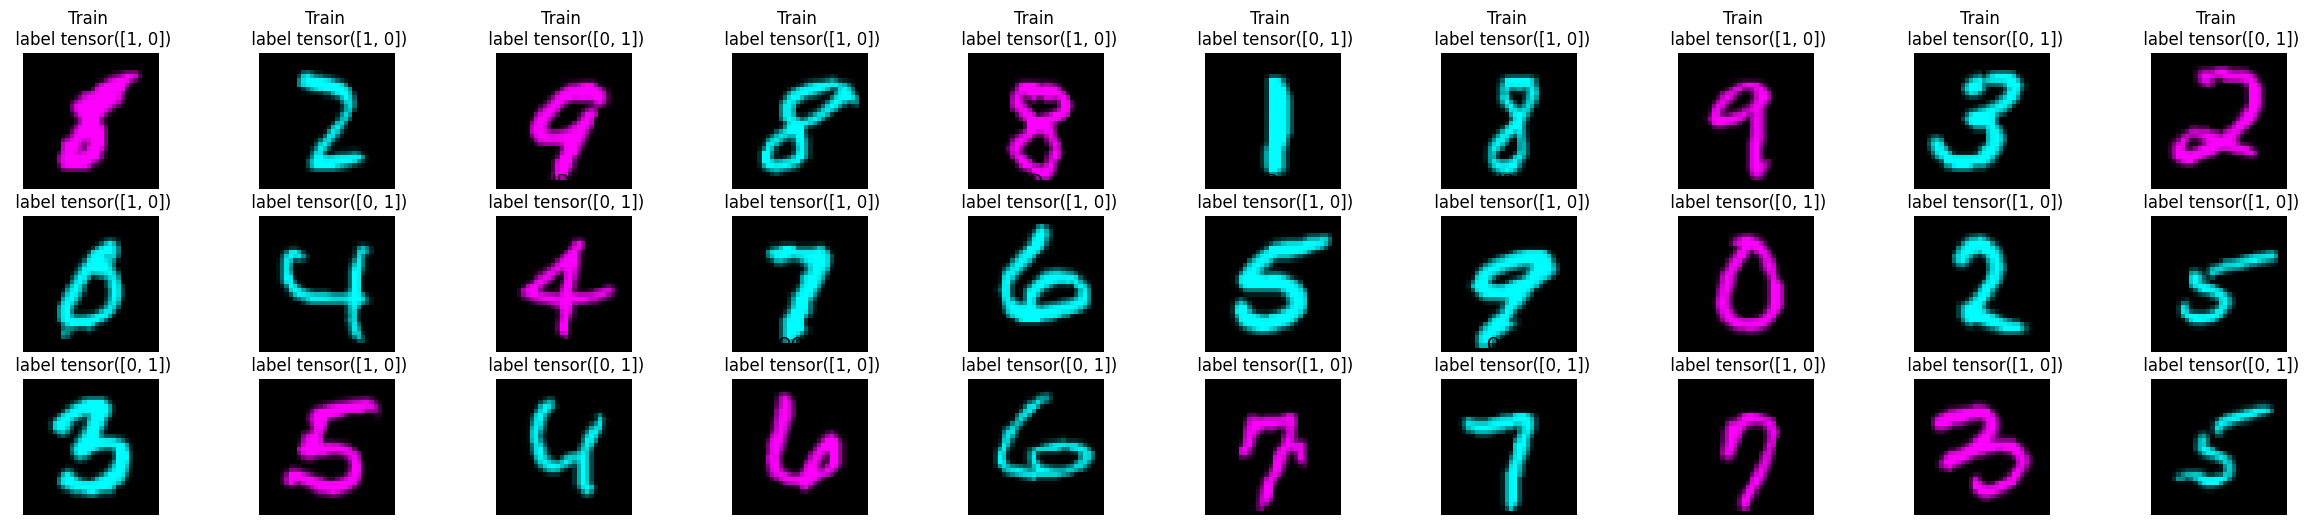

In [1]:
import torch
from torch.utils.data import Dataset, random_split
from typing import Literal
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms

from oxels.datasets.dg import MultiDomainDataset


class DGDataset(Dataset):
    splits = {
        "train": 0.8,
        "val": 0.1,
        "test": 0.1,
    }

    def __init__(
        self,
        *,
        path: str,
        dataset: str = "camelyon17",
        split: Literal["train", "val", "test"] = "train",
        domain_split: Literal["id", "ood"] = "id",
        seed: int = 0,
        augmentations: callable = None,
    ):
        self.path = Path(path)
        self.split = split
        self.domain_split = domain_split
        self.augmentations = augmentations
        self.dataset = self._get_dataset(dataset, seed=seed)

    def __getitem__(self, item):
        with torch.device("cpu"):
            rgb, label, _ = self.dataset.__getitem__(item)
        rgb = rgb.numpy(force=True)
        return rgb, label

    def __len__(self):
        return len(self.dataset)

    def _get_raw_dataset(self, dataset: str):
        match dataset.lower():
            case "camelyon17":
                from oxels.datasets.dg import Camelyon17

                return Camelyon17(self.path, download=True)
            case "coloredmnist":
                from oxels.datasets.dg import ColoredMNIST

                return ColoredMNIST(self.path, download=True, transform=self.augmentations)
            case "fmowregion":
                from oxels.datasets.dg import FMoWRegion

                return FMoWRegion(self.path, download=True)
            case "fmowyear":
                from oxels.datasets.dg import FMoWYear

                return FMoWYear(self.path, download=True)
            case "officehome":
                from oxels.datasets.dg import OfficeHome

                return OfficeHome(self.path, download=True)
            case "pacs":
                from oxels.datasets.dg import PACS

                return PACS(self.path, download=True)
            case "rotatedmnist":
                from oxels.datasets.dg import RotatedMNIST

                return RotatedMNIST(self.path, download=True)
            case "terraincognita":
                from oxels.datasets.dg import TerraIncognita

                return TerraIncognita(self.path, download=True)
            case "vlcs":
                from oxels.datasets.dg import VLCS

                return VLCS(self.path, download=True)
            case "povertymapurbanicity":
                from oxels.datasets.dg import PovertyMapUrbanicity

                return PovertyMapUrbanicity(self.path, download=True)
            case "povertymapcountry":
                from oxels.datasets.dg import PovertyMapCountry

                return PovertyMapCountry(self.path, download=True)
            case other:
                raise NotImplementedError(f"Unrecognized dataset: {other}")

    def _get_splits(self, dataset, seed):
        if self.domain_split == "id":
            domains = dataset.all_domains[:-1]
        elif self.domain_split == "ood":
            domains = dataset.all_domains[-1:]
        else:
            raise ValueError(f"Expected domain_split to be 'id' or 'ood', got {self.domain_split}.")

        # get the full domains
        domains = [dataset.domain(d) for d in domains]

        if self.domain_split != "ood":
            # get the seeded random splits for the given domain
            split = list(self.splits.keys()).index(self.split)
            generator = torch.Generator().manual_seed(seed)
            domains = [random_split(d, list(self.splits.values()), generator=generator)[split] for d in domains]

        return domains

    def _get_dataset(self, dataset, seed=0):
        raw_dataset = self._get_raw_dataset(dataset)
        splits = self._get_splits(raw_dataset, seed)

        return MultiDomainDataset(
            *splits, in_distribution=self.domain_split == "id", n_domains=len(raw_dataset.all_domains)
        )

dataset_train = DGDataset(
    path="datasets",
    dataset="ColoredMNIST",
    split="train",
    domain_split="id",
    seed=0,
    augmentations=transforms.Compose([
        transforms.Resize((32, 32))
    ]),
)
labels_train = torch.zeros(2)
for i in range(len(dataset_train)):
    _, label = dataset_train[i]
    labels_train += label
print(f"Train labels: {labels_train}")

dataset_id = DGDataset(
    path="datasets",
    dataset="ColoredMNIST",
    split="val",
    domain_split="id",
    seed=0,
    augmentations=transforms.Compose([
        transforms.Resize((32, 32))
    ]),
)
labels_id = torch.zeros(2)
for i in range(len(dataset_id)):
    _, label = dataset_id[i]
    labels_id += label
print(f"ID labels: {labels_id}")

dataset_ood = DGDataset(
    path="datasets",
    dataset="ColoredMNIST",
    split="val",
    domain_split="ood",
    seed=0,
    augmentations=transforms.Compose([
        transforms.Resize((32, 32))
    ]),
)
labels_ood = torch.zeros(2)
for i in range(len(dataset_ood)):
    _, label = dataset_ood[i]
    labels_ood += label
print(f"OOD labels: {labels_ood}")

n_samples = 10
fig, axs = plt.subplots(3, n_samples, figsize=(n_samples*3, 2*3))
for i in range(n_samples):
    img, label = dataset_train[i]
    axs[0, i].imshow(img.transpose(1, 2, 0))
    axs[0, i].axis("off")
    axs[0, i].set_title(f"Train \n label {label}")

for i in range(n_samples):
    img, label = dataset_id[i]
    axs[1, i].imshow(img.transpose(1, 2, 0))
    axs[1, i].axis("off")
    axs[1, i].set_title(f"ID \n label {label}")

for i in range(n_samples):
    img, label = dataset_ood[i]
    axs[2, i].imshow(img.transpose(1, 2, 0))
    axs[2, i].axis("off")
    axs[2, i].set_title(f"OOD \n label {label}")
plt.show()

# Load Backbone

In [4]:
import os


backbone_run_name = "amber-terrain-77"
ckpt_dir = os.path.join("lightning_logs", str(backbone_run_name))
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "r") as f:
    backbone_run_id = f.read().strip()
backbone = ColoredMNISTModel.load_from_checkpoint(os.path.join(ckpt_dir, "best_model.ckpt"))
print(f"Loaded model from {os.path.join(ckpt_dir, 'best_model.ckpt')} with run id {backbone_run_id} and name {backbone_run_name}")
num_oxels = backbone.hparams.num_oxels

Loaded model from lightning_logs/amber-terrain-77/best_model.ckpt with run id x73jq8at and name amber-terrain-77


# Create Downstream Model

In [5]:
import torch
import torch.nn as nn


class ConvPoolDown(nn.Module):
    """
    Spatial Aggregation of oxels while preserving the oxel channel
    """
    def __init__(self, out_size: int, in_channels: int, out_channels: int, kernel_size: int=3, padding: int=1, stride: int=2, groups: int=1):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.out_size = out_size
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride, groups=groups)
        self.pool = nn.AdaptiveAvgPool2d(out_size)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = x.flatten(start_dim=1)
        return x

    def get_output_shape(self):
        return self.out_channels * self.out_size * self.out_size

class LinearClassifier(nn.Module):
    def __init__(self, down_op: nn.Module, num_classes: int):
        super().__init__()
        self.down_op = down_op
        self.num_classes = num_classes
        self.linear = nn.Linear(down_op.get_output_shape(), num_classes)

    def forward(self, x):
        embedding = self.down_op(x)
        prediction = self.linear(embedding)
        return prediction


num_classes = 2
down_op = ConvPoolDown(out_size=8, in_channels=num_oxels, out_channels=8, groups=8)
classifier = LinearClassifier(down_op, num_classes)
print(f"Downstream model: {down_op}")
print(f"Downstream model parameters: {sum(p.numel() for p in down_op.parameters())}")
print(f"Downstream model: {classifier}")
print(f"Downstream model parameters: {sum(p.numel() for p in classifier.parameters())}")
print(f"Downstream model input shape: {down_op(torch.randn(1, num_oxels, 32, 32)).shape}")
print(f"Downstream model output shape: {classifier(torch.randn(1, num_oxels, 32, 32)).shape}")

Downstream model: ConvPoolDown(
  (conv): Conv2d(32, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=8)
  (pool): AdaptiveAvgPool2d(output_size=8)
)
Downstream model parameters: 296
Downstream model: LinearClassifier(
  (down_op): ConvPoolDown(
    (conv): Conv2d(32, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=8)
    (pool): AdaptiveAvgPool2d(output_size=8)
  )
  (linear): Linear(in_features=512, out_features=2, bias=True)
)
Downstream model parameters: 1322
Downstream model input shape: torch.Size([1, 512])
Downstream model output shape: torch.Size([1, 2])


# DG Linear Classifier Model

In [6]:
import os
from torch.utils.data import DataLoader
from torchvision import transforms
from torchmetrics import Accuracy
import lightning as L
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from oxels.models.metrics_mixin import MetricsMixin


class DGLinearClassifier(MetricsMixin, L.LightningModule):
    def __init__(
        self,
        backbone: nn.Module,
        head: nn.Module,
        dataset_name: str,
        train_batch_size: int,
        val_batch_size: int,
        num_oxels: int = 64,
        image_size: int = 256,
        weight_decay: float = 0.004,
        learning_rate: float = 1e-3,
        lr_pct_start: float = 0.05,
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
    ):
        super().__init__()
        self.save_hyperparameters(
            ignore=["backbone", "head", "dataset_name"],
        )
        self.backbone = backbone
        self.backbone.freeze()
        self.head = head
        self.dataset_name = dataset_name
        self.loss_fn = nn.CrossEntropyLoss()
        self.train_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.val_acc = Accuracy(task="binary", num_classes=head.num_classes)
        self.test_acc = Accuracy(task="binary", num_classes=head.num_classes)

    def forward(self, x):
        oxels = self.backbone(x)
        prediction = self.head(oxels)
        return prediction

    def compute_loss(self, batch):
        images, labels = batch
        logits = self(images) # some scalar
        labels = labels.to(dtype=logits.dtype)
        loss = self.loss_fn(logits, labels)
        return loss

    def compute_metrics(self, batch):
        images, labels = batch
        logits = self(images)
        labels = labels.to(dtype=logits.dtype)
        loss = self.loss_fn(logits, labels)
        preds = torch.argmax(logits, dim=1)
        # choose the right Accuracy object based on stage
        # Lightning will set self.training, self.validating, self.testing flags
        if labels.ndim > 1:
            labels = torch.argmax(labels, dim=1)
        if self.trainer.training:
            acc = self.train_acc(preds, labels)
        elif self.trainer.validating:
            acc = self.val_acc(preds, labels)
        else:  # testing
            acc = self.test_acc(preds, labels)

        return {
            "loss": loss,
            "accuracy": acc,
        }

    def configure_optimizers(self):
        lr = self.hparams.learning_rate
        wd = self.hparams.weight_decay

        # only use parameters that requires grad
        params = [p for p in self.parameters() if p.requires_grad]
        optimizer = AdamW(params, lr=lr, weight_decay=wd, betas=(0.9, 0.99))
        scheduler = OneCycleLR(
            optimizer,
            max_lr=lr,
            total_steps=self.trainer.estimated_stepping_batches,
            div_factor=self.hparams.lr_div_factor,
            final_div_factor=self.hparams.lr_final_div_factor,
            pct_start=self.hparams.lr_pct_start,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        metrics = self.compute_metrics(batch)
        prefix = "validation/" if dataloader_idx == 0 else "validation/ood/"
        for key, value in metrics.items():
            key = f"{prefix}{key}"
            self.log(key,
                     value,
                     on_step=False,
                     on_epoch=True,
                     sync_dist=True,
                     prog_bar=(dataloader_idx == 0),  # maybe only show ID in prog bar
                     logger=True)

        return metrics["loss"]

    def train_dataloader(self):
        dataset = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="train",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
        )
        return DataLoader(
            dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        val_id = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="id",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
        )

        val_ood = DGDataset(
            path="datasets",
            dataset=self.dataset_name,
            split="val",
            domain_split="ood",
            seed=0,
            augmentations=transforms.Compose([
                transforms.Resize((self.hparams.image_size, self.hparams.image_size))
            ]),
        )

        return [DataLoader(val_id, batch_size=self.hparams.val_batch_size, shuffle=False, pin_memory=True, num_workers=len(os.sched_getaffinity(0)), drop_last=False),
                DataLoader(val_ood, batch_size=self.hparams.val_batch_size, shuffle=False, pin_memory=True, num_workers=len(os.sched_getaffinity(0)), drop_last=False)]



# Putting things together: BACKBONE + CLASSIFIER -> Training

In [13]:
down_op = ConvPoolDown(out_size=1, in_channels=num_oxels, out_channels=num_oxels, groups=num_oxels)
classifier = LinearClassifier(down_op, num_classes=2)

In [14]:
import lightning as L
import torch
from lightning.pytorch import callbacks
from lightning.pytorch.loggers import WandbLogger

import wandb
from oxels.callbacks import ShowOxels


torch.cuda.empty_cache()
torch.set_float32_matmul_precision("medium")

print("Device Count:", torch.cuda.device_count())
project = "ColoredMNIST-testing"
total_steps = 30_000
image_size = 32
num_nodes = 1
num_devices = 1
train_batch_size = 128
val_batch_size = 256
learning_rate = 5e-3
lr_pct_start = 0.05
weight_decay = 1e-4

model_config = dict(
    num_oxels=num_oxels,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e4,
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    image_size=image_size,
)

trainer_config = dict(
    gradient_clip_val=3.0,
    gradient_clip_algorithm="value",
    max_steps=total_steps,
    accelerator="gpu",
    strategy="auto",
    devices=num_devices,
    precision="16-mixed",
    num_nodes=num_nodes,
)

model = DGLinearClassifier(
    backbone=backbone,
    head=classifier,
    dataset_name="ColoredMNIST",
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    num_oxels=num_oxels,
    image_size=image_size,
    weight_decay=weight_decay,
    learning_rate=learning_rate,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e4)

with torch.device("cpu"):
    train_images = [model.train_dataloader().dataset.dataset[i][0] for i in range(4)]
    train_images = torch.stack(train_images)
    validation_images = [model.val_dataloader()[0].dataset.dataset[i][0] for i in range(4)]
    validation_images = torch.stack(validation_images)
    validation_images_ood = [model.val_dataloader()[1].dataset.dataset[i][0] for i in range(4)]
    validation_images_ood = torch.stack(validation_images_ood)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters: ", num_parameters)
config = model_config | trainer_config


Device Count: 1
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST data

In [15]:
run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir="wandb_results",
)

logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters
wandb.summary["backbone_run_id"] = backbone_run_id
wandb.summary["backbone_run_name"] = backbone_run_name
wandb.summary["model_type"] = "LCSpatialAggregation"
run_name = wandb.run.name
run_id = wandb.run.id
print(f"name: {run_name} \t run id:{run_id}")

ckpt_dir = os.path.join("lightning_logs", str(run_name))
# make sure the directory exists
os.makedirs(ckpt_dir, exist_ok=True)
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "w") as f:
    f.write(run_id)
trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss/dataloader_idx_0",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        ShowOxels(images=train_images, every_n_epochs=10, caption="Train Oxels"),
        ShowOxels(images=validation_images, every_n_epochs=10, caption="Validation Oxels"),
        ShowOxels(images=validation_images_ood, every_n_epochs=10, caption="Validation OOD Oxels"),
    ],
    logger=logger,
)

try:
    trainer.fit(model)
    result = trainer.callback_metrics["validation/loss/dataloader_idx_0"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nbracher/anaconda3/envs/oxels/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/nbracher/Documents/Projects/oxels/notebooks/lightning_logs/mild-darkness-87 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | backbone  | ColoredMNISTModel | 993 K  | eval 
1 | head      | LinearClassifier  | 386    | train
2 | loss_fn   | CrossEntropyLoss  | 0      | train
3 | train_acc | BinaryAccuracy    | 0      | train
4 | val_acc   | BinaryAccuracy    | 0      | train
5 | test_acc  | BinaryAccuracy    | 0      | train
--------------------------------------------------------
386       Trainable params
993 K     Non-trainable params
994 K     Total params

name: mild-darkness-87 	 run id:0elpb5zk


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.
Found existing ColoredMNIST dataset in datasets, skipping download.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=30000` reached.


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
lr-AdamW,▄▅▆▇███████▇▇▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▄▃▃▂▂▂▂▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇█████
training/accuracy_epoch,▁▂▃▃▄▅▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇████████▇██
training/accuracy_step,▁▅▅▄▅▅▅▅▅▇▅▆▇▆▄▄▆▇▆▆▅▇▆▅█▅▆▆▆▆▆▅▅█▇▆▆▆▅▆
training/loss_epoch,█▆▅▅▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
training/loss_step,▇▇▆▁▃█▇▄▄▄▄▄█▅▅▅▅▂▅▃▄▂▂▂▅▃▂▅▄▇▅▃▅▆▃▁▇▅▆▂
validation/accuracy/dataloader_idx_0,▁▄▄▆▆▆▇▇▇▇▆▇▇▇▇▇▇▇▇▇███▇▇██▇█████▇███▇▇▇
validation/loss/dataloader_idx_0,█▅▄▅▄▃▃▃▃▃▂▂▂▃▃▃▃▃▂▃▃▃▃▂▂▂▂▁▂▂▁▂▂▂▁▂▂▂▃▁
validation/ood/accuracy/dataloader_idx_1,▁▄▄▅▆▇▇▆▆▇▇▇▇▇▇█▇██▇███▇▇█████████▇█████
validation/ood/loss/dataloader_idx_1,█▅▄▄▃▃▃▂▂▂▂▂▂▁▂▂▂▂▁▁▂▂▁▁▂▂▂▂▁▂▂▁▁▁▁▁▁▂▁▁
